<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [1]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
    !pip install langdetect
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [1]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt
import numpy as np

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display
from langdetect import detect

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [3]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_1.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [ ]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
# df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_1.gzip.parquet


## Output Path


In [5]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04


In [6]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
33553,a885e35f47b37dbf8d6523e6d1cb326750ca14ff3e,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc...,b9052708258f305d40d00a13826c6cb32520a2d48c,en,None,None,2011-11-16 21:22:51,305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff,"I retweet nude boob, breast and busty tits lin...",30947,5,2009-06-22,False,None,None,"[tits, twitterafterdark, sexy, nsfw, winning, ...",[https://28996df6cb2615e6d83cc955a21f300da9aa1...,"[fc90d644020a23df2eb4c26373d222fb48c2e8eb6b, 3...",True
9427,97268ff33a5391a7c9e98970ab8fd7a77ad3ffd684,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @7...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,None,4193919dab08bcb9f8024e31e56e7c100f8e6aca21,c81c8ad3384e63e1027a12aa487c58ba9967bb8121,2011-04-15 03:31:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[],[],"[c81c8ad3384e63e1027a12aa487c58ba9967bb8121, 7...",False
199,b69f3d10bbc8126734f0125bd30acd8e679729d98f,I feel like I'm wasting my time -,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2010-08-22 23:57:47,bde5efb0a08f2c83b40b97fbe57eb62e1f5d7fd5e4,None,179,161,2009-08-14,True,7dd12ede51c1c9036a60dd2057e5afed31187437c5,e292b4add24048c9baa59bca3d74f1fa1ad36b8cc4,[],[],[7dd12ede51c1c9036a60dd2057e5afed31187437c5],True
12447,f8967f139e2f255f184c5b6b41db467527f42fce90,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Al...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2011-05-10 19:00:00,86f64e2fce5d67c880f1d220f60205d26692ae9e6d,Abogada. Madre de dos príncipes.,135,141,2009-06-19,False,None,None,[],[],[9d72355c890e1bb8530156865c0d4172bc3a2926cd],False
39489,57785b5ad7e2d3d4b6f82b66cba9b0bc76a740e758,"#Messi, feliz porque su país se siente “orgull...",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,es,None,None,2012-01-09 15:49:03,f72876e465be073b329ab221a21558f99a6535793b,El Diario informativo más comprometido con la ...,2237136,4021,2008-04-08,False,None,None,[Messi],[https://c45b5d07c7547ecc3bec497b91663a6170362...,[],True


## Logs

In [7]:
from functools import wraps
from datetime import datetime



REPORT_PATH = output_folder_path / "progress_report.txt"

def write_report(msg: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"{timestamp} | {msg}"

    print(line)
    with open(REPORT_PATH, "a") as f:
        f.write(line + "\n")


def report_done(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as e:
            write_report(f"FAILED: {func.__name__} | {e}")
            raise
    return wrapper

# Dataset Statistics

In [8]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]
start_date = df["post_time"].min().strftime("%Y-%m")
end_date = df["post_time"].max().strftime("%Y-%m")

stats_text = [
    f"Posts time range: {start_date} → {end_date}",
    "",
    f"{'df shape:':<40} {df.shape}",
    f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)",
    f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)",
    f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)",
]

# print to console
print("\n".join(stats_text))

# save to file
if output_folder_path:
    output_folder_path = Path(output_folder_path)
    report_path = output_folder_path / "dataset_summary.txt"
    with open(report_path, "w") as f:
        f.write("\n".join(stats_text))

print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

Posts time range: 2010-08 → 2012-04

df shape:                                (100, 19)
df posts with hashtags # shape:          (37, 19)  (37.00%)
df posts with account_mentions @ shape:  (51, 19)  (51.00%)
df posts with urls shape:                (25, 19)  (25.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | nd

# Clean Text

## Clean text With Entities

In [9]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token

In [10]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [11]:
df["clean_text_with_entities"] = df["post_text"].apply(clean_text)

## Clean Text Without Enttities

In [12]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [13]:
df["clean_text_without_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [14]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_without_enteties"]].sample(n=20)

,post_text,clean_text_without_enteties
29600,fuiz sorry sorry sorry sorry sorry sorry sorry sorry,fuiz sorry sorry sorry sorry sorry sorry sorry sorry
22062,When people ask stupid questions iam obligated to give a sarcastic reply.,when people ask stupid questions iam obligated to give a sarcastic reply.
725,"@399eae03073d41d7fd34ebb8aa422ebf737a05db13 coloca música fuerte, para que no escuches","<USER> coloca música fuerte, para que no escuches"
36958,Alguien podría enumerar los logros de la Defensoría del Pueblo @ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de #Cacho?,alguien podría enumerar los logros de la defensoría del pueblo <USER> ; sin contar la defensa de cacho?
15267,"Toner Compatible Alternativo HP nuevo https://617e751312138be767e62217f8d27088bb65b1efc8 en #VeAvisos de #peru, #avisos #clasificados","toner compatible alternativo hp nuevo <URL> en veavisos de peru, avisos clasificados"
18619,"Con su nuevo uniforme, Ecuador se transformó en el primer equipo africano en jugar Copa América.","con su nuevo uniforme, ecuador se transformó en el primer equipo africano en jugar copa américa."
41514,¿De que sabor va a querer su Bon Ice? #PreguntasDelTercerMundo,¿de que sabor va a querer su bon ice? preguntasdeltercermundo
13624,Y no hay palabras con las que explicarte cómo fue el momento en el que pude hablarte.,y no hay palabras con las que explicarte cómo fue el momento en el que pude hablarte.
38340,@9ab70660ad2dd43b296a55e65165de3389fb6158a0 @f60e68650505c5be1fa359bcb6279c4d6c8ff514a1 hasta ahora soñamos con la parte del atardecer volando como un ave con el amor de nuestras vidas ♥ #someday,<USER> <USER> hasta ahora soñamos con la parte del atardecer volando como un ave con el amor de nuestras vidas ♥ someday
21123,"Gracias compadre RT @21115fa4d2b7dd9572c10f56142ae66cf1a1f83397: #FF @6033eb82d8a67288ea6b8be0c05d87bee3685e9dfc porque es la #1, a mi compadre @3fc52aec07a2a29f2e826754c36c4a4f6f5356dfb7, son gente que no (cont) https://6bcd27a1040ad1c6f04548acb7cb13f159e9252920","gracias compadre rt <USER>: ff <USER> porque es la 1, a mi compadre <USER>, son gente que no (cont) <URL>"


# Translation to English

## Language Codes 

In [ ]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str, text: str, undefined_code = "und") -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in map, auto-detect the language from text.
    Args:
        lang_code (str): Post language code.
        text (str): Post text for detection.
        undefined_code (str): Default code to return if no mapping is found.
    Returns:
        str: NLLB-200 language code.
    """
    nllb_mapping = {

    # 🌍 Africa
    "af": "afr_Latn",   # Afrikaans
    "am": "amh_Ethi",   # Amharic
    "sw": "swh_Latn",   # Swahili

    # 🌍 Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "fa": "pes_Arab",   # Persian (Farsi)
    "ur": "urd_Arab",   # Urdu

    # 🌍 Europe
    "be": "bel_Cyrl",   # Belarusian
    "bg": "bul_Cyrl",   # Bulgarian
    "bs": "bos_Latn",   # Bosnian
    "ca": "cat_Latn",   # Catalan
    "cs": "ces_Latn",   # Czech
    "cy": "cym_Latn",   # Welsh
    "da": "dan_Latn",   # Danish
    "de": "deu_Latn",   # German
    "el": "ell_Grek",   # Greek
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "et": "est_Latn",   # Estonian
    "fi": "fin_Latn",   # Finnish
    "fr": "fra_Latn",   # French
    "ga": "gle_Latn",   # Irish
    "gl": "glg_Latn",   # Galician
    "hr": "hrv_Latn",   # Croatian
    "hu": "hun_Latn",   # Hungarian
    "is": "isl_Latn",   # Icelandic
    "it": "ita_Latn",   # Italian
    "lt": "lit_Latn",   # Lithuanian
    "lv": "lvs_Latn",   # Latvian
    "mk": "mkd_Cyrl",   # Macedonian
    "mt": "mlt_Latn",   # Maltese
    "nl": "nld_Latn",   # Dutch
    "no": "nob_Latn",   # Norwegian (Bokmål)
    "pl": "pol_Latn",   # Polish
    "pt": "por_Latn",   # Portuguese
    "ro": "ron_Latn",   # Romanian
    "ru": "rus_Cyrl",   # Russian
    "sk": "slk_Latn",   # Slovak
    "sl": "slv_Latn",   # Slovenian
    "sq": "als_Latn",   # Albanian
    "sr": "srp_Cyrl",   # Serbian (Cyrillic default)
    "sv": "swe_Latn",   # Swedish
    "uk": "ukr_Cyrl",   # Ukrainian

    # 🌍 Caucasus & Central Asia
    "az": "azj_Latn",   # Azerbaijani
    "hy": "hye_Armn",   # Armenian
    "ka": "kat_Geor",   # Georgian
    "kk": "kaz_Cyrl",   # Kazakh
    "mn": "mon_Cyrl",   # Mongolian
    "uz": "uzn_Latn",   # Uzbek

    # 🌍 South Asia
    "bn": "ben_Beng",   # Bengali
    "gu": "guj_Gujr",   # Gujarati
    "hi": "hin_Deva",   # Hindi
    "kn": "kan_Knda",   # Kannada
    "ml": "mal_Mlym",   # Malayalam
    "mr": "mar_Deva",   # Marathi
    "ne": "npi_Deva",   # Nepali
    "pa": "pan_Guru",   # Punjabi
    "ta": "tam_Taml",   # Tamil
    "te": "tel_Telu",   # Telugu

    # 🌍 Southeast Asia
    "id": "ind_Latn",   # Indonesian
    "ms": "zsm_Latn",   # Malay
    "th": "tha_Thai",   # Thai
    "tl": "tgl_Latn",   # Tagalog
    "vi": "vie_Latn",   # Vietnamese
    "km": "khm_Khmr",   # Khmer

    # 🌍 East Asia
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean
    "zh": "zho_Hans",   # Chinese (Simplified)
}

    # 1. direct mapping
    if lang_code in nllb_mapping:
        return nllb_mapping[lang_code]

    # 2. language detection
    try:
        detected = detect(text)
    except Exception as e:
        write_report(f"Language detection failed: {e} | lang_code={lang_code} | text={text[:100]}")
        return undefined_code  # undetermined

    # 3. mapping detected language
    if detected in nllb_mapping:
        return nllb_mapping[detected]

    write_report(f"No NLLB mapping for detected language: {detected}")
    return lang_code

In [ ]:
# Change post_language to NLLB-200 codes
undefined_code = "und"

# Before mapping
print("Before mapping to NLLB-200 codes:")
language_value_counts = df["post_language"].value_counts()
print(language_value_counts)
write_report(f"Undefined post language percentage **before** mapping: {language_value_counts.get('und', 0) / len(df) * 100:.2f}%")

# Apply mapping
df["post_language"] = df.apply(lambda row: map_to_nllb_code(row['post_language'], row['clean_text_without_enteties'], undefined_code), axis=1)

# After mapping to NLLB-200 codes:
print("After mapping to NLLB-200 codes:")
language_value_counts = df["post_language"].value_counts()
print(language_value_counts)
write_report(f"Undefined post language percentage **after** mapping: {language_value_counts.get('und', 0) / len(df) * 100:.2f}%")

In [ ]:
# Remove post with undefined language
undefined_count = df[df['post_language'] == undefined_code].shape[0]
write_report(f"Removing {undefined_count} posts with undefined language code {undefined_code}")
df = df[df['post_language'] != undefined_code].copy()

## Translation

In [ ]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
write_report(f"Loaded {MODEL_NAME} model and tokenizer on {device}")

translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, torch_dtype=torch.float16, max_length=512, batch_size=8)
write_report(f"Translation pipeline created.")

Using device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda


In [20]:
import subprocess
import torch 

def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n], i

@report_done
def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_without_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
    call_batch: int = 16,          # how many texts you feed per call (NOT pipeline batch_size)
    max_new_tokens: int = 512,      # cap generated length (huge VRAM saver)
) -> pd.DataFrame:

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    write_report(subprocess.check_output("nvidia-smi", shell=True).decode())

    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):
        texts = group[text_col].astype(str).tolist()
        indexes = group.index.to_list()

        translated_all = [None] * len(texts)

        def run_translate(batch_texts, s_lang, t_lang):
            # inference_mode saves memory vs no_grad in many cases
            with torch.inference_mode():
                outs = translation_pipe(
                    batch_texts,
                    src_lang=s_lang,
                    tgt_lang=t_lang,
                    # truncation=True,                # avoid super-long inputs
                    max_new_tokens=max_new_tokens,  # avoid 1024-token generations
                )
            return [o["translation_text"] for o in outs]

        # Case 1: normal translation
        if src_lang != target_lang:
            write_report(f"{len(texts)} posts: {src_lang} → {target_lang}")

            for batch_texts, start in _chunks(texts, call_batch):
                batch_trans = run_translate(batch_texts, src_lang, target_lang)
                translated_all[start:start+len(batch_trans)] = batch_trans

                # cleanup between calls (helps on long runs)
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

        # Case 2: back-translation
        elif backtranslate_same_lang:
            write_report(f"{target_lang} → {pivot_lang} → {target_lang}")

            for batch_texts, start in _chunks(texts, call_batch):
                pivot_texts = run_translate(batch_texts, target_lang, pivot_lang)
                back_texts = run_translate(pivot_texts, pivot_lang, target_lang)
                translated_all[start:start+len(back_texts)] = back_texts

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

        # assign back
        result_df.loc[indexes, out_col] = translated_all

    return result_df

In [ ]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)
write_report("Translation completed.")

df shape: (100, 21)
2026-01-04 09:30:59 | Sun Jan  4 09:30:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 30%   48C    P0             58W /  300W |    2798MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----

Translating by language:   0%|          | 0/10 [00:00<?, ?it/s]

2026-01-04 09:30:59 | 1 posts: deu_Latn → eng_Latn
2026-01-04 09:31:00 | eng_Latn → spa_Latn → eng_Latn
2026-01-04 09:31:13 | 2 posts: est_Latn → eng_Latn
2026-01-04 09:31:14 | 1 posts: fra_Latn → eng_Latn
2026-01-04 09:31:14 | 1 posts: hrv_Latn → eng_Latn
2026-01-04 09:31:14 | 1 posts: pol_Latn → eng_Latn
2026-01-04 09:31:14 | 5 posts: por_Latn → eng_Latn


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2026-01-04 09:31:14 | 2 posts: slv_Latn → eng_Latn
2026-01-04 09:31:21 | 63 posts: spa_Latn → eng_Latn
2026-01-04 09:31:29 | 2 posts: tgl_Latn → eng_Latn
2026-01-04 09:31:29 | Completed: transformers_translator


In [22]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_without_enteties", "translated_post"]]

,clean_text_without_enteties,translated_post
17746,<USER> te voy a enviar por twitter una que otra costilla xd jeje,<USER> I'm gonna tweet you one or the other rib xd jeje
18471,"but 140 characters only covers one of the voices in my head,what about the others? what about them? likealot","But 140 characters only cover one of the voices in my head, what about the others?"
17523,mañana 7.30 am en telerama. inquietudes sobre el metro,Tomorrow at 7.30 am on TV. Worries about the subway
9413,me lleva el diablo!,Take the devil away from me!
11732,radio26 matanzas la naturaleza convida: niños y jóvenes matanceros resultaron premiados en... <URL> prensamatanzas cu,Radio 26 killings nature invites: children and young slaughterers were rewarded with...
13624,y no hay palabras con las que explicarte cómo fue el momento en el que pude hablarte.,And there are no words to describe the moment I was able to talk to you.
18619,"con su nuevo uniforme, ecuador se transformó en el primer equipo africano en jugar copa américa.","In their new uniform, Ecuador became the first African team to play the Copa América."
3928,<USER> gracias! ♥,Thank you! ♥
24148,que bello es soñar con <USER> la extraño):,How beautiful it is to dream of the stranger.
8270,np all back,np everything backwards


# Remove Engllish Stopwords

In [23]:
from nltk.corpus import stopwords
import nltk

In [24]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    if not text:
        return text
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
df["clean_text_with_entities"] = df["clean_text_with_entities"].apply(remove_stopwords)
df["clean_text_without_enteties"] = df["clean_text_without_enteties"].apply(remove_stopwords)
df["translated_post"] = df["translated_post"].apply(remove_stopwords)

In [26]:
df[["post_text", "clean_text_with_entities"]].head(20)

,post_text,clean_text_with_entities
33553,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,mention_fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: url_28996df6cb2615e6d83cc955a21f300da9aa185a73 mention_305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff hashtag_tits hashtag_twitterafterdark hashtag_sexy hashtag_nsfw hashtag_winning hashtag_amateur
9427,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @72c233209dc9fa95258de4150952791cc619e258cc Q ASCO!!!,mention_c81c8ad3384e63e1027a12aa487c58ba9967bb8121 mention_72c233209dc9fa95258de4150952791cc619e258cc q asco!!!
199,I feel like I'm wasting my time -,feel wasting time -
12447,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Alguien sabe q pasa en la ARC a la altura del antiguo peaje de Hoyo de la Puerta? Ahí mucha cola...,mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...
39489,"#Messi, feliz porque su país se siente “orgulloso” de él https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff","hashtag_messi , feliz porque su país se siente “orgulloso” de él url_c45b5d07c7547ecc3bec497b91663a6170362bc8ff"
42724,@db015c48d7cb5bd6f438327e963b2022e2b9f4b986 hahahaha i am for sumwer ano no yet.lolz,mention_db015c48d7cb5bd6f438327e963b2022e2b9f4b986 hahahaha sumwer ano yet.lolz
10822,@9e58fca9edb89eec88dfc3d3fd34feeafd42af5856 feliz día a los diseñadores gráficos,mention_9e58fca9edb89eec88dfc3d3fd34feeafd42af5856 feliz día los diseñadores gráficos
49498,Para #barcelona #bsc ganarle a #LIGA #ldu no es un sueño... Es mision imposible! Catedra en la cancha y en las gradas Grande LIGA y MB &lt;3,para hashtag_barcelona hashtag_bsc ganarle hashtag_liga hashtag_ldu es un sueño... es mision imposible! catedra en la cancha en las gradas grande liga mb &lt;3
4144,#animalnocturno,hashtag_animalnocturno
36958,Alguien podría enumerar los logros de la Defensoría del Pueblo @ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de #Cacho?,alguien podría enumerar los logros de la defensoría del pueblo mention_ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de hashtag_cacho ?


# Handling *None* Cells

In [ ]:
display(df[df["translated_post"].isna()][["post_text", "post_language", "clean_text_without_enteties", "translated_post"]])

# Check if more than 5% of posts are untranslated
num_untranslated = df["translated_post"].isna().sum()
total_posts = len(df)
percentage_untranslated = (num_untranslated / total_posts) * 100

write_report(f"Untranslated posts: {num_untranslated}/{total_posts} ({percentage_untranslated:.2f}%)")
if percentage_untranslated > 10:
    write_report(f"Handling None Cells: More than 10% of posts are untranslated: {percentage_untranslated:.2f}%")
    raise ValueError(f"More than 10% of posts are untranslated: {percentage_untranslated:.2f}%")

# Fill untranslated posts with original cleaned text
df["translated_post"] = df["translated_post"].fillna(df["clean_text_without_enteties"])
write_report("Filled untranslated posts with original cleaned text.")

,post_text,post_language,clean_text_without_enteties,translated_post


2026-01-04 09:31:30 | Untranslated posts: 0/100 (0.00%)


# English Topic Clustering

Note: the topic clustering doent influenced by the entities since it is preformed on the text without the entitites.

## Utils


### Posts Topic Stats

In [28]:
@report_done
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [29]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path: str | Path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")

    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )


    plt.tight_layout()


    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [30]:
@report_done
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_control_col: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO rate: 1 - mean(is_control)
    author_io_rate = 1 - df.groupby(author_col)[is_control_col].mean()
    author_io_tag = (author_io_rate >= threshold).astype(int)

    topic_author_df = df[[topic_col, author_col]].drop_duplicates().copy()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if absent in data
    stats = stats.reindex(columns=[0, 1], fill_value=0).rename(
        columns={0: "control_accounts", 1: "io_accounts"}
    ).reset_index()

    stats["total_accounts"] = stats["control_accounts"] + stats["io_accounts"]
    stats["io_percent"] = (stats["io_accounts"] / stats["total_accounts"]).mul(100)

    return stats

In [31]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    model_name: str,
    output_folder_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        model_name: Model name for title / filename.
        output_folder_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")

    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats["total_accounts"].sum()}",
        ],
        loc="best",
    )

    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / f"{model_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.show()
    plt.close()

### Embeddings

In [32]:
from sklearn.preprocessing import normalize

# List of posts' text
translated_clean_posts_text_lst = df["translated_post"].to_list()

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(translated_clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [ ]:
import subprocess

@report_done
def english_BERTopic_modeling(
        posts_text_lst: list[str], 
        embeddings: np.ndarray, 
        output_folder_path: str | Path = "", 
        min_topic_size: int = 100
    ):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    # print memory summary
    write_report(f"english_BERTopic_modeling: \n {subprocess.check_output('nvidia-smi', shell=True).decode()}")

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model

In [ ]:
import math

min_topic_size = int(min(len(df) / 10, int(math.log(100, 1.1)))) # 100 -> 10, 50K -> 113, 1M -> 144
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(translated_clean_posts_text_lst, embeddings, output_folder_path = output_folder_path, min_topic_size = min_topic_size)

df["BERTopic_topic"] = BERTopic_topic
df["BERTopic_prob"] = BERT_probs


BERTopic_model.get_topic_info()

2026-01-04 09:31:35,266 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-01-04 09:31:35 | english_BERTopic_modeling: 
 Sun Jan  4 09:31:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 34%   60C    P0             81W /  300W |    3654MiB /  49140MiB |     33%      Default |
|                                         |                        |                  N/A

2026-01-04 09:31:45,480 - BERTopic - Dimensionality - Completed ✓
2026-01-04 09:31:45,480 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-04 09:31:45,489 - BERTopic - Cluster - Completed ✓
2026-01-04 09:31:45,492 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-04 09:31:45,506 - BERTopic - Representation - Completed ✓
2026-01-04 09:31:45,516 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04
2026-01-04 09:31:45 | Completed: english_BERTopic_modeling


,Topic,Count,Name,Representation,Representative_Docs
0,-1,39,-1_url_thank_going_user,"[url, thank, going, user, anyone, boy, ecuador, first, dies, much]","[going try skins. tried looked, except that's going try now., new uniform, ecuador became first african team play copa américa., barcelona bsc win league ldu dream... impossible mission! chair pitch grades big league mb &lt;3]"
1,0,28,0_hey_user_sorry_me,"[hey, user, sorry, me, sister, comrade, away, url, draft, birthday]","[thanks comrade <user>: ff <user> number 1, comrade <user>, (cont) <url>, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey!, <user> hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey h..."
2,1,19,1_talk_book_life_thats,"[talk, book, life, thats, actually, 140, absolutely, able, always, answer]","[""keep positive life difficult situations, successful life ever""., happen, parents must streets, neighbourhoods demanding work, rich agriculture., actually talk saying something that's real... talk.]"
3,2,14,2_url_night_hp_newsletters,"[url, night, hp, newsletters, classified, compatible, thursdays, rain, toner, turkey]","[new hours: night: rain, 40°f; thursdays: showers, 47°f; thursdays night: rain, 39°f; <url> fb, compatible toner hp 53x 100% ... <url> turkey wines, classified wines, toner compatible alternative hp new <url> turkey newsletters, classified newsletters]"


In [35]:
@report_done
def make_topic_top_posts_table(
    df,
    topic_col="BERTopic_topic",
    prob_col="BERTopic_prob",
    text_col="translated_post",
    top_k=5,
    output_folder_path: Path | str | None = None,
):
    """Make a df with the top k posts with the highest BERTopic probability for each topic."""

    top_posts = (
        df[[topic_col, prob_col, text_col]]
        .dropna(subset=[topic_col, prob_col, text_col])
        .sort_values([topic_col, prob_col], ascending=[True, False])
        .drop_duplicates(subset=[topic_col, text_col])  # remove duplicates within topic
        .groupby(topic_col)
        .head(top_k)
        .copy()
    )

    top_posts["rank"] = top_posts.groupby(topic_col).cumcount() + 1

    top_posts = top_posts.pivot(
        index=topic_col,
        columns="rank",
        values=text_col,
    )

    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        df_output_path = output_folder_path / "topics_top_posts.parquet"
        top_posts.to_parquet(df_output_path, compression="gzip")
        print(f"Topic posts table is saved to {df_output_path}")

    return top_posts

In [36]:
topic_posts_table = make_topic_top_posts_table(df, output_folder_path = output_folder_path)
display(topic_posts_table.head())

Topic posts table is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/topics_top_posts.parquet
2026-01-04 09:31:45 | Completed: make_topic_top_posts_table


rank,1,2,3,4,5
BERTopic_topic,,,,,
-1,disgusting thing!,anyone what's going arch height old doorhole toll?,"messi, happy country feels proud",happy day graphic designers,barcelona bsc win league ldu dream... impossible mission! chair pitch grades big league mb &lt;3
0,<user> hahahaha sumwer yet.lolz,ah! facebook open t________t,bby <user> &lt;3,<user> it!! haha,"<user> plays loud music, hear"
1,feel wasting time.,that's way is.,"140 characters cover voices head, others?","absolutely right, perfect... patience, exact word.","ask stupid questions, forced give sarcastic answer."
2,regulation shall enter force twentieth day following publication official journal european union.,200 dead fire honduran prison.,epileptic patients can't find medication treatment <url> right health guaranteed vzla!!!,"toner compatible alternative hp new <url> turkey newsletters, classified newsletters",live: mass march support vladimir putin moscow russian news <url>


2026-01-04 09:31:45 | Completed: make_topic_stats
plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/BERTopic_topic_clustering.png


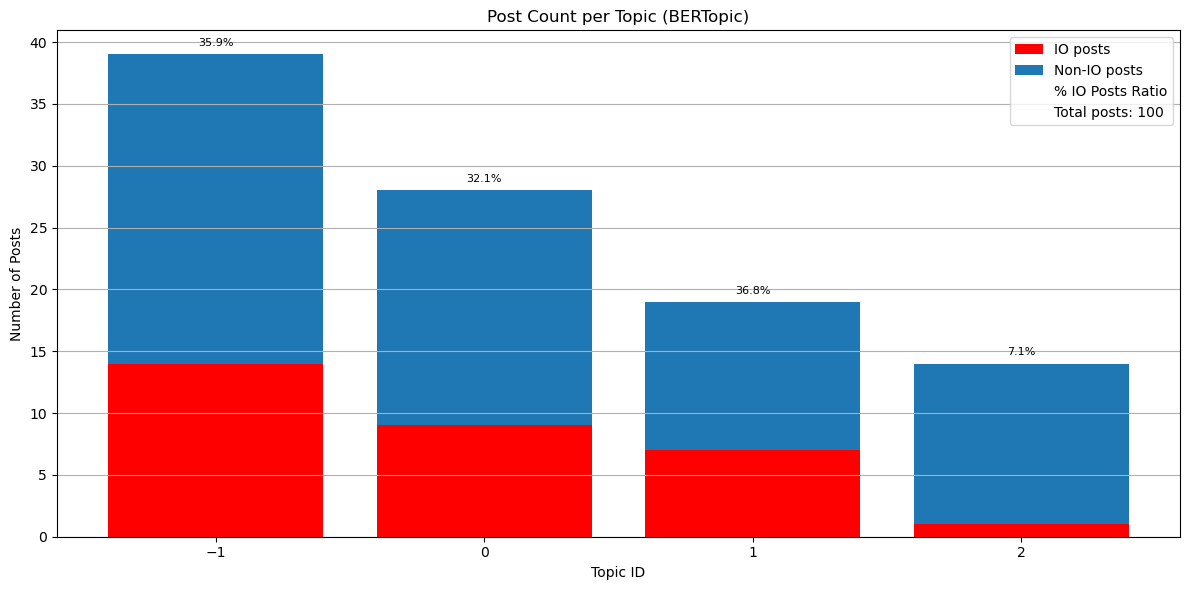

In [37]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

2026-01-04 09:31:46 | Completed: make_topic_account_stats


author_io_tag,BERTopic_topic,control_accounts,io_accounts,total_accounts,io_percent
0,-1,23,4,27,14.814815
1,0,18,3,21,14.285714
2,1,12,3,15,20.000000
3,2,12,1,13,7.692308


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/BERTopic_topic_accounts.png


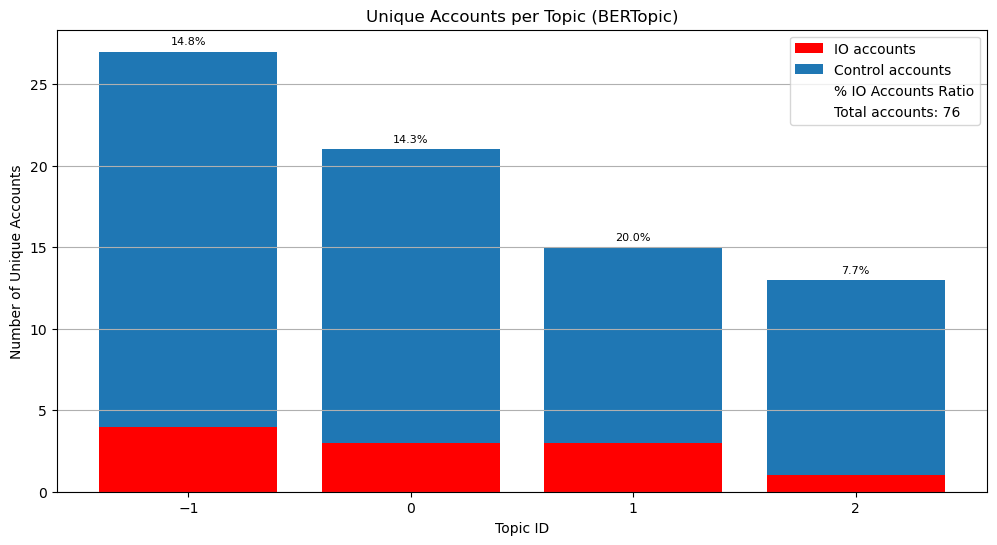

In [38]:
topic_col_name = "BERTopic_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "BERTopic", output_folder_path)

In [39]:
try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/home/amitner/.local/lib/python3.12/site-packages/umap/spectral.py:519: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.



## K-Means

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import subprocess

@report_done
def auto_kmeans_topics(embeddings, k_min=30, k_max=200, step = 4):
    best_k = None
    best_score = -1
    best_labels = None

    # print memory summary
    write_report(f"auto_kmeans_topics: \n {subprocess.check_output('nvidia-smi', shell=True).decode()}")

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [ ]:
import math

# n = len(df)

# k_min = max(3,#  int(math.log(n)))
# print(f"k_min = {k_min}")
# k_max = min(200 ,int(math.sqrt(n)))
# print(f"k_max = {k_max}")
# labels, best_k = auto_kmeans_topics(embeddings, k_min=k_min, k_max=k_max)

labels, best_k = auto_kmeans_topics(embeddings, k_min=4, k_max=40)
df["K_Means_topic"] = labels
print(f"\nBest k: {best_k}")
df.head()

k_min = 4
k_max = 10
2026-01-04 09:31:47 | auto_kmeans_topics: 
 Sun Jan  4 09:31:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 34%   58C    P0             71W /  300W |    3654MiB /  49140MiB |      0%      Default |
|                                         |                        |       

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,hashtags,urls,account_mentions,is_control,clean_text_with_entities,clean_text_without_enteties,translated_post,BERTopic_topic,BERTopic_prob,K_Means_topic
33553,a885e35f47b37dbf8d6523e6d1cb326750ca14ff3e,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,b9052708258f305d40d00a13826c6cb32520a2d48c,eng_Latn,None,None,2011-11-16 21:22:51,305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff,"I retweet nude boob, breast and busty tits links. https://75338c1b201c7d83996054cfa846b0ac2190b00f6f From fc194b71dfcd65cdd736cd1b015183ed2e09a07ddf",30947,...,"[tits, twitterafterdark, sexy, nsfw, winning, amateur]",[https://28996df6cb2615e6d83cc955a21f300da9aa185a73],"[fc90d644020a23df2eb4c26373d222fb48c2e8eb6b, 305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff]",True,mention_fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: url_28996df6cb2615e6d83cc955a21f300da9aa185a73 mention_305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff hashtag_tits hashtag_twitterafterdark hashtag_sexy hashtag_nsfw hashtag_winning hashtag_amateur,<user> fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: <url> <user> tits twitterafterdark sexy nsfw winning amateur,regulation shall enter force twentieth day following publication official journal european union.,2,1.0,3
9427,97268ff33a5391a7c9e98970ab8fd7a77ad3ffd684,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @72c233209dc9fa95258de4150952791cc619e258cc Q ASCO!!!,2727201c363b6fc4afe259ba4094ae0c49cb4df224,por_Latn,4193919dab08bcb9f8024e31e56e7c100f8e6aca21,c81c8ad3384e63e1027a12aa487c58ba9967bb8121,2011-04-15 03:31:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,[],[],"[c81c8ad3384e63e1027a12aa487c58ba9967bb8121, 72c233209dc9fa95258de4150952791cc619e258cc]",False,mention_c81c8ad3384e63e1027a12aa487c58ba9967bb8121 mention_72c233209dc9fa95258de4150952791cc619e258cc q asco!!!,<user> <user> q asco!!!,disgusting thing!,-1,0.0,0
199,b69f3d10bbc8126734f0125bd30acd8e679729d98f,I feel like I'm wasting my time -,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,eng_Latn,None,None,2010-08-22 23:57:47,bde5efb0a08f2c83b40b97fbe57eb62e1f5d7fd5e4,None,179,...,[],[],[7dd12ede51c1c9036a60dd2057e5afed31187437c5],True,feel wasting time -,feel wasting time -,feel wasting time.,1,1.0,0
12447,f8967f139e2f255f184c5b6b41db467527f42fce90,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Alguien sabe q pasa en la ARC a la altura del antiguo peaje de Hoyo de la Puerta? Ahí mucha cola...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,spa_Latn,None,None,2011-05-10 19:00:00,86f64e2fce5d67c880f1d220f60205d26692ae9e6d,Abogada. Madre de dos príncipes.,135,...,[],[],[9d72355c890e1bb8530156865c0d4172bc3a2926cd],False,mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...,<user> alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...,anyone what's going arch height old doorhole toll?,-1,0.0,3
39489,57785b5ad7e2d3d4b6f82b66cba9b0bc76a740e758,"#Messi, feliz porque su país se siente “orgulloso” de él https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,spa_Latn,None,None,2012-01-09 15:49:03,f72876e465be073b329ab221a21558f99a6535793b,"El Diario informativo más comprometido con la gente de Ecuador. En Facebook, Instagram y TikTok nos encuentras como f6f1a125d387fda775d529ffec68c7b1926448ff99",2237136,...,[Messi],[https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff],[],True,"hashtag_messi , feliz porque su país se siente “orgulloso” de él url_c45b5d07c7547ecc3bec497b91663a6170362bc8ff","messi, feliz porque su país se siente “orgulloso” de él <u

2026-01-04 09:31:47 | Completed: make_topic_stats
plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/K-Means_topic_clustering.png


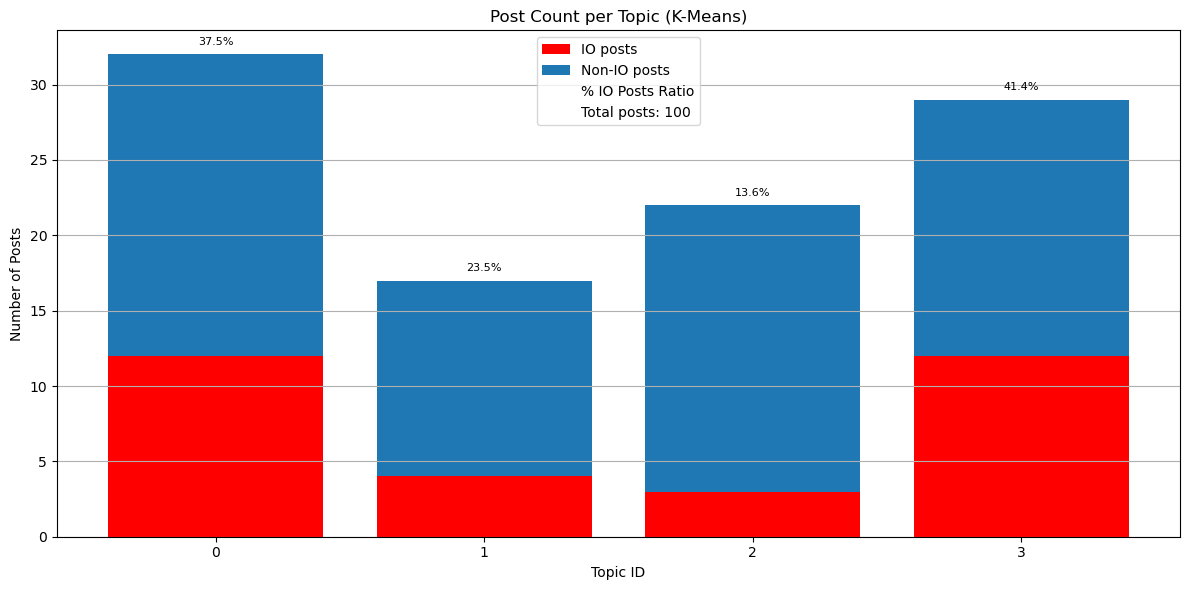

In [42]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

2026-01-04 09:31:48 | Completed: make_topic_account_stats


author_io_tag,K_Means_topic,control_accounts,io_accounts,total_accounts,io_percent
0,0,19,3,22,13.636364
1,1,12,3,15,20.000000
2,2,19,2,21,9.523810
3,3,16,4,20,20.000000


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/K_Means_topic_accounts.png


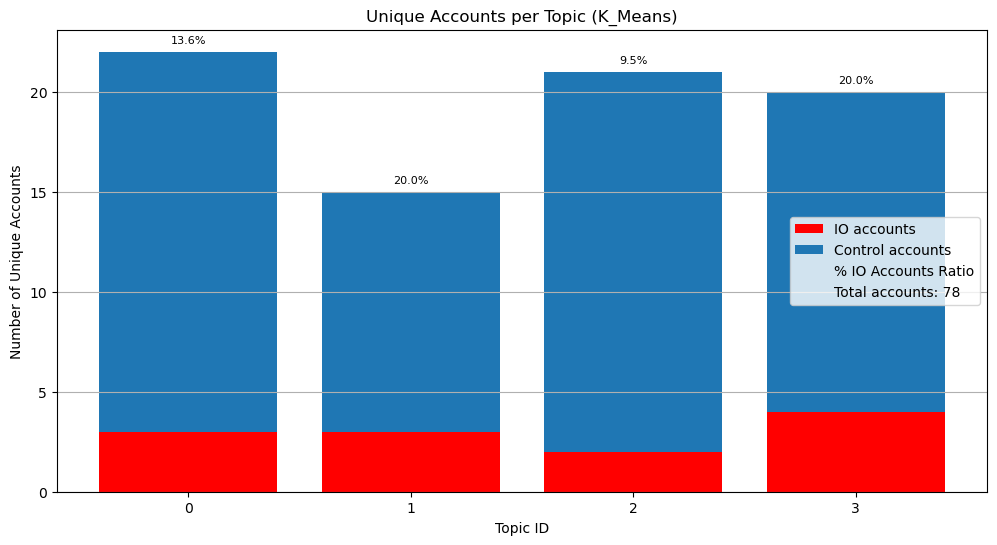

In [43]:
topic_col_name = "K_Means_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "K_Means", output_folder_path)

# Named Entity Recognition

In [44]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

@report_done
def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [45]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["translated_post"].to_list())

2026-01-04 09:31:52 | Completed: extract_ner_entities


In [46]:
# display post with ner entities
df.loc[df["ner_entities"].astype(bool), ["post_text", "translated_post", "ner_entities"]].head()

,post_text,translated_post,ner_entities
33553,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,regulation shall enter force twentieth day following publication official journal european union.,"[journal, european, union@@]"
49498,Para #barcelona #bsc ganarle a #LIGA #ldu no es un sueño... Es mision imposible! Catedra en la cancha y en las gradas Grande LIGA y MB &lt;3,barcelona bsc win league ldu dream... impossible mission! chair pitch grades big league mb &lt;3,"[barcelona, c]"
36958,Alguien podría enumerar los logros de la Defensoría del Pueblo @ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de #Cacho?,anyone list achievements user people's defense without counting cacho defense?,"[c@@, acho]"
43106,Más de 200 muertos en incendio en cárcel de #Honduras. https://1fc26ec3624b619ad0c1ad0e2faa26d02797241f7a #Mundo,200 dead fire honduran prison.,"[hon@@, duran]"
1414,AHH! mi facebook no me abre T________T,ah! facebook open t________t,[facebook]


# Clean Entities

In [47]:
@report_done
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``.
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [48]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

2026-01-04 09:31:52 | Completed: clean_entity_columns


# Entities Statistics

In [49]:
@report_done
def entity_topic_counts(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str,
) -> pd.DataFrame:
    """Return entity-topic count matrix.

    Args:
        df: Input DataFrame.
        entity_col: Column with entity IDs (list-like).
        topic_col: Column with topic labels.

    Returns:
        DataFrame with entities as index, topics as columns, counts as values.
    """
    
    df_exploded = (
        df[[entity_col, topic_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col, topic_col])
    )

    return pd.crosstab(
        index=df_exploded[entity_col],
        columns=df_exploded[topic_col],
        dropna=False,
    )


In [50]:
def plot_entity_topic_counts(
    entity,
    entity_topic_counts,
    clustering_model: str = "",
    output_folder_path=None,
):
    """Plot how many times a given entity appears in each topic.

    Args:
        entity: Entity ID that exists in entity_topic_counts.index.
        entity_topic_counts: DataFrame from pd.crosstab (index=entity, columns=topic, values=counts).
        clustering_model: Optional label to annotate the plot.
        output_folder_path: If given (Path-like), saves PNG to this folder.
    """
    # Extract row for chosen entity (entity is in the index)
    counts = entity_topic_counts.loc[entity]  # Series: topic_id -> count

    # Topic columns
    topic_cols = list(entity_topic_counts.columns)


    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts.values)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")

    # Metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    plt.tight_layout()

    # Save if path provided
    if output_folder_path is not None:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()
    plt.close()

2026-01-04 09:31:53 | Completed: entity_topic_counts


BERTopic_topic,-1,0,1,2
ner_entities,,,,
acho,1,0,0,0
african,1,0,0,0
aguayan,0,0,0,1
apple,0,0,0,1
at@@,0,0,0,1


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/acho_topic_distribution.png


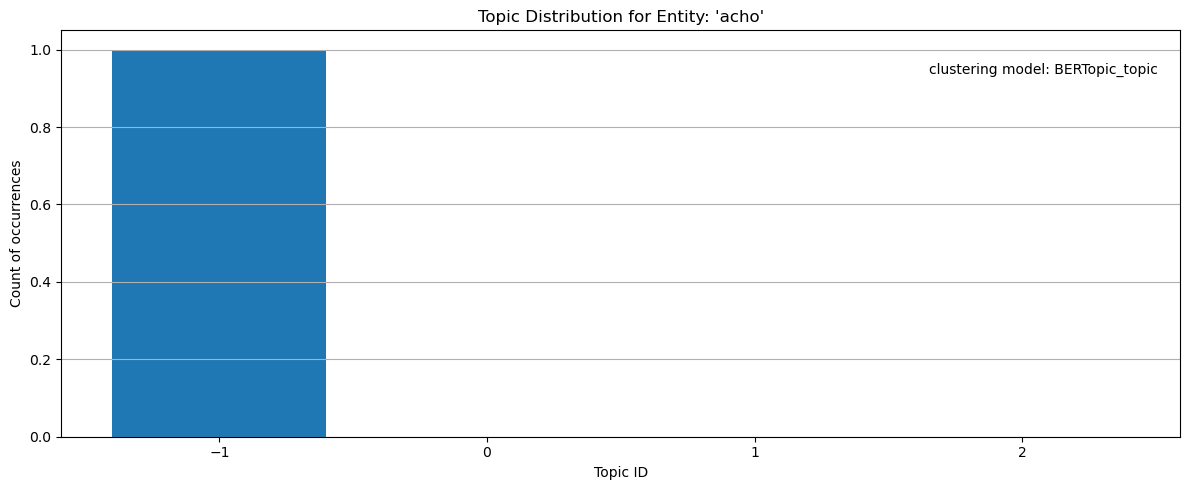

In [51]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_counts_df = entity_topic_counts(df, entity_col_name, topic_col)
display(entity_topic_counts_df.head())

entity = entity_topic_counts_df.index[0]   # first entity
plot_entity_topic_counts(entity=entity, entity_topic_counts=entity_topic_counts_df, clustering_model=topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [52]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic                  | int32
ner_entities                   | list


In [53]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)


write_report("Finised Runnign Susscsefuly")

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2026_01_04/Topic_Ner_Ecuador_part_1.gzip.parquet
2026-01-04 09:31:53 | Finised Runnign Susscsefuly
